In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df.shape

(10000, 3)

In [4]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Probability'>

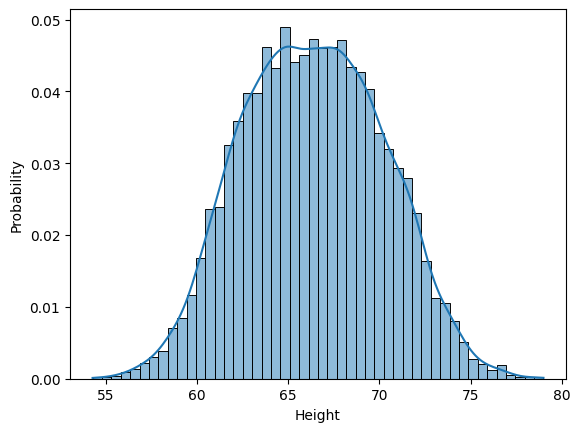

In [5]:
sns.histplot(df['Height'],kde=True,stat='probability')

<Axes: xlabel='Height'>

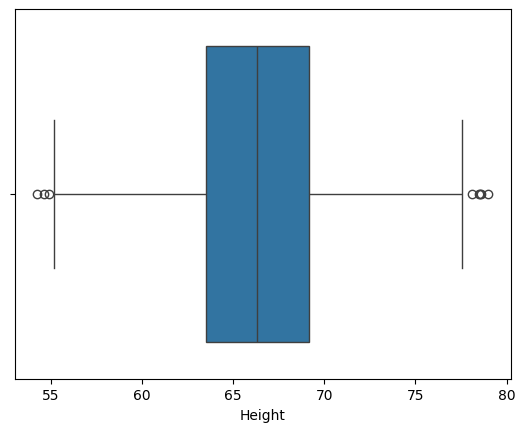

In [6]:
sns.boxplot(x=df['Height'])

In [7]:
upeer_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)
print(upeer_limit)
print(lower_limit)

74.7857900583366
58.13441158671655


In [8]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

In [9]:
df['Height'].describe

<bound method NDFrame.describe of 0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64>

<Axes: xlabel='Height', ylabel='Probability'>

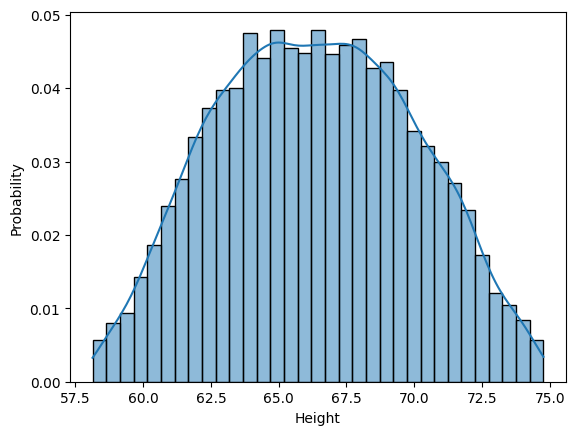

In [10]:
sns.histplot(new_df['Height'],kde=True,stat='probability')

<Axes: xlabel='Height'>

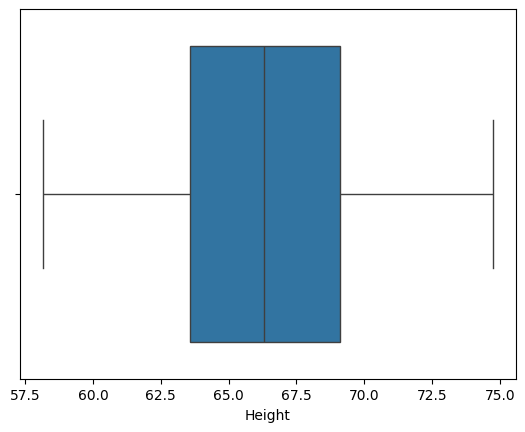

In [11]:
sns.boxplot(x = new_df['Height'])

In [12]:
### cappint --- > Winsorization
df['Height'] = np.where(df['Height'] >= upeer_limit,
         upeer_limit,
         np.where(df['Height'] <= lower_limit,
         lower_limit,
         df['Height'])
        )


In [13]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Probability'>

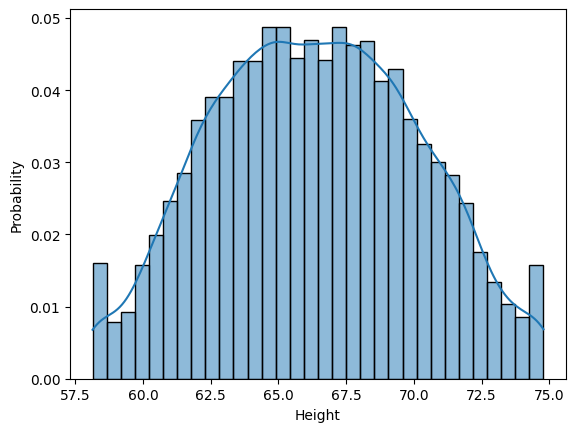

In [14]:
sns.histplot(df['Height'],kde=True,stat='probability')

<Axes: xlabel='Height'>

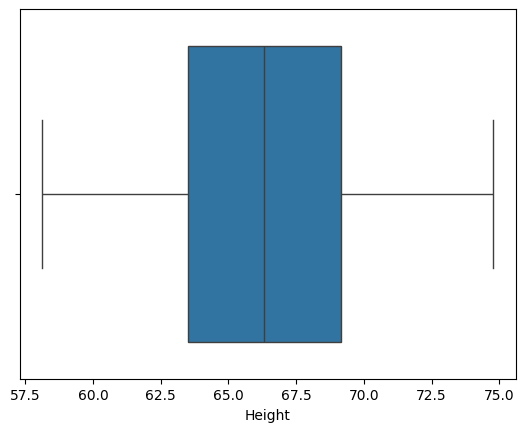

In [15]:
sns.boxplot(x=df['Height'])